# Assignment 2: Urban Flooding Modeling

Zhanchao Yang

## Instruction
- Please download DEM in Pennsylvania and run the HAND model
- Please download the DEM tiles for Pennsylvania
- Run the HAND model to estimate the inundation depth for each tile
- Export the results to geotiff
- Mosaic the exposed results into a complete geotiff for whole Pennsylvania.
- Upload your notebook and submit a report to present your map for PA.

*Here is a hint about how to conduct the analysis for one tile. You can reference this for your homework. You need to generate the results for the whole of Pennsylvania. You will need to use a loop to download DEM tiles for Pennsylvania and conduct the mosaicing to generate the image for the whole state.*

*Use the download-dem.ipynb to download the DEM data for any location.*

## 0. Setup

In [1]:
import os
import warnings

import numpy as np

# pysheds 0.5 calls np.in1d, removed in NumPy 2.0 -> grid.accumulation() fails without this
if not hasattr(np, "in1d"):
    np.in1d = np.isin

warnings.filterwarnings("ignore", message=".*Setting the shape on a NumPy array.*")

import requests
import geopandas as gpd
import rasterio as rio
from rasterio.enums import Resampling

from pysheds.grid import Grid

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from shapely.geometry import box

In [2]:
DEM_DIR = "data/dem"          # raw USGS tiles
HAND_DIR = "output/hand"      # per-tile HAND
DEPTH_DIR = "output/depth"    # per-tile inundation depth
MOSAIC_DIR = "output"         # statewide mosaics

for d in (DEM_DIR, HAND_DIR, DEPTH_DIR, MOSAIC_DIR):
    os.makedirs(d, exist_ok=True)

ACC_THRESHOLD = 200   # cells of upstream accumulation that define a drainage channel
DEPTH_THRESHOLD = 5   # metres of water in the channel (flood scenario)

## 1. Study area: Pennsylvania

In [3]:
pa_file = "data/pa_boundary.geojson"

if not os.path.exists(pa_file):
    states = gpd.read_file(
        "https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
    )
    pa = states[states.STUSPS == "PA"].to_crs(epsg=4326)
    pa[["STATEFP", "STUSPS", "NAME", "geometry"]].to_file(pa_file, driver="GeoJSON")

pa = gpd.read_file(pa_file)
pa_geom = pa.geometry.union_all()

print("CRS:", pa.crs)
print("bounds (minx, miny, maxx, maxy):", pa.total_bounds)

CRS: EPSG:4326
bounds (minx, miny, maxx, maxy): [-80.519851  39.719799 -74.689561  42.516072]


## 2. Which DEM tiles cover Pennsylvania?

In [4]:
import math


def tile_name(north, west):
    """USGS tile name from its NW corner, e.g. (41, -77) -> 'n41w077'."""
    return f"n{north:02d}w{abs(west):03d}"


def tile_box(north, west):
    """Footprint of a tile: it spans north-1..north and west..west+1."""
    return box(west, north - 1, west + 1, north)


minx, miny, maxx, maxy = pa.total_bounds

tiles = [
    tile_name(north, west)
    for north in range(math.floor(miny) + 1, math.ceil(maxy) + 1)
    for west in range(math.floor(minx), math.ceil(maxx))
    if tile_box(north, west).intersects(pa_geom)
]

print(f"{len(tiles)} tiles cover Pennsylvania:")
print(tiles)

25 tiles cover Pennsylvania:
['n40w081', 'n40w080', 'n40w079', 'n40w078', 'n40w077', 'n40w076', 'n41w081', 'n41w080', 'n41w079', 'n41w078', 'n41w077', 'n41w076', 'n41w075', 'n42w081', 'n42w080', 'n42w079', 'n42w078', 'n42w077', 'n42w076', 'n42w075', 'n43w081', 'n43w080', 'n43w079', 'n43w078', 'n43w077']


## 3. Download the DEM tiles

In [5]:
BASE_URL = "https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1/TIFF/current"


def download_tile(name, save_dir=DEM_DIR):
    """Download one 1-arc-second DEM tile. Returns the local path, or None if unavailable."""
    out_file = os.path.join(save_dir, f"{name}.tif")

    if os.path.exists(out_file):
        return out_file

    url = f"{BASE_URL}/{name}/USGS_1_{name}.tif"
    response = requests.get(url, stream=True)

    if response.status_code != 200:
        print(f"  unavailable ({response.status_code}): {url}")
        return None

    with open(out_file, "wb") as f:
        for chunk in response.iter_content(1024 * 1024):
            f.write(chunk)

    return out_file


dem_files = {}

for n, name in enumerate(tiles, start=1):
    path = download_tile(name)
    if path:
        dem_files[name] = path
        size_mb = os.path.getsize(path) / 1024 ** 2
        print(f"[{n}/{len(tiles)}] {name}  {size_mb:.0f} MB")

print(f"\n{len(dem_files)} of {len(tiles)} tiles available locally")

[1/25] n40w081  57 MB
[2/25] n40w080  54 MB
[3/25] n40w079  56 MB
[4/25] n40w078  56 MB
[5/25] n40w077  53 MB
[6/25] n40w076  53 MB
[7/25] n41w081  55 MB
[8/25] n41w080  55 MB
[9/25] n41w079  54 MB
[10/25] n41w078  55 MB
[11/25] n41w077  55 MB
[12/25] n41w076  56 MB
[13/25] n41w075  57 MB
[14/25] n42w081  48 MB
[15/25] n42w080  53 MB
[16/25] n42w079  53 MB
[17/25] n42w078  54 MB
[18/25] n42w077  54 MB
[19/25] n42w076  53 MB
[20/25] n42w075  55 MB
[21/25] n43w081  14 MB
[22/25] n43w080  26 MB
[23/25] n43w079  51 MB
[24/25] n43w078  53 MB
[25/25] n43w077  51 MB

25 of 25 tiles available locally


## 4. The HAND model on one tile

HAND (Height Above Nearest Drainage) re-expresses elevation relative to the stream a cell drains into,
instead of relative to sea level. A cell 2 m above its own stream is exposed to flooding even if it sits
at 400 m elevation; a cell 200 m above its stream is not.

This section follows the steps laid out in `source/urban-flood-vulnerability.ipynb` — detect pits, fill
pits, detect depressions, fill depressions, resolve flats, compute accumulation, then HAND and the
inundation extent — run on `n41w077` (central PA, the Susquehanna valley) before looping over the
whole state.

In [6]:
demfile = dem_files["n41w077"]

# Read raw DEM
grid = Grid.from_raster(demfile)
dem = grid.read_raster(demfile)

print("shape:  ", dem.shape)
print("CRS:    ", grid.crs.srs.split('"')[1])
print("extent: ", grid.extent)
print("nodata: ", dem.nodata)
print("elevation range: %.1f to %.1f m" % (dem[dem != dem.nodata].min(), dem.max()))

shape:   (3612, 3612)
CRS:     NAD83
extent:  (-77.00166666658271, -75.99833333321607, 39.99833333341752, 41.00166666678416)
nodata:  -999999.0
elevation range: -21.8 to 638.0 m


#### Detecting pits

Pits are single cells surrounded by higher terrain, so water routed into them cannot leave. They are
mostly artefacts of the elevation survey, and they break flow routing if left in place.

pits found: 66478


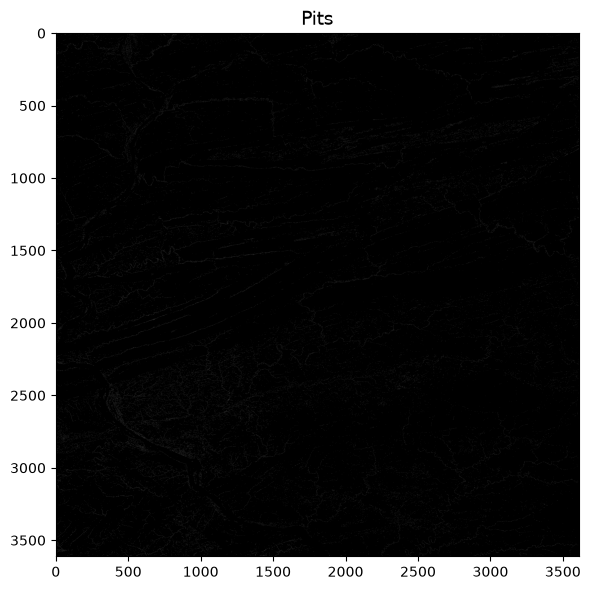

In [7]:
# Detect pits
pits = grid.detect_pits(dem)

print("pits found:", pits.sum())

fig, ax = plt.subplots(figsize=(7, 6))
plt.imshow(pits, cmap="Greys_r", zorder=1)
plt.title("Pits", size=14)
plt.tight_layout()
plt.show()

#### Filling pits

In [8]:
# Fill pits
pit_filled_dem = grid.fill_pits(dem)
pits = grid.detect_pits(pit_filled_dem)
assert not pits.any()

print("pits remaining:", pits.sum())

pits remaining: 0


#### Detecting depressions

Depressions are the multi-cell version of the same problem — a basin with no outlet.

cells in depressions: 0


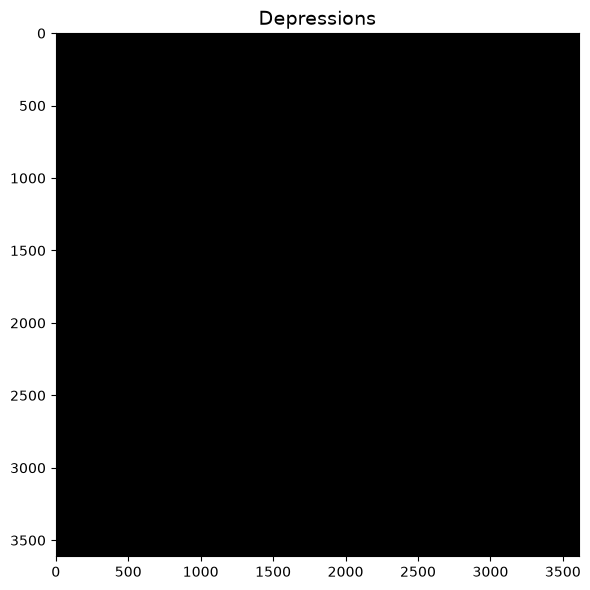

In [9]:
# Detect depressions
depressions = grid.detect_depressions(pit_filled_dem)

print("cells in depressions:", depressions.sum())

fig, ax = plt.subplots(figsize=(7, 6))
plt.imshow(depressions, cmap="Greys_r", zorder=1)
plt.title("Depressions", size=14)
plt.tight_layout()
plt.show()

#### Filling depressions

In [10]:
# Fill depressions
flooded_dem = grid.fill_depressions(pit_filled_dem)
depressions = grid.detect_depressions(flooded_dem)
assert not depressions.any()

print("depressions remaining:", depressions.sum())

depressions remaining: 0


#### Resolving flats

Filling a depression leaves a perfectly flat surface, where D8 has no steepest neighbour to pick.
`resolve_flats` adds a tiny gradient so flow has a direction to follow.

In [11]:
# Resolve flats
inflated_dem = grid.resolve_flats(flooded_dem)
flats = grid.detect_flats(inflated_dem)

print("flat cells remaining:", flats.sum())
print("cells raised by conditioning: %.2f%%"
      % (100 * (np.asarray(inflated_dem) != np.asarray(dem)).mean()))

flat cells remaining: 63
cells raised by conditioning: 2.80%


#### Computing flow direction and accumulation

In [12]:
# Compute flow direction based on corrected DEM
fdir = grid.flowdir(inflated_dem)

# Compute flow accumulation based on computed flow direction
acc = grid.accumulation(fdir)

channels = acc > ACC_THRESHOLD
print(f"max upstream cells: {int(acc.max()):,}")
print(f"cells classified as channel (acc > {ACC_THRESHOLD}): {100 * channels.mean():.2f}%")

max upstream cells: 2,163,960
cells classified as channel (acc > 200): 3.95%


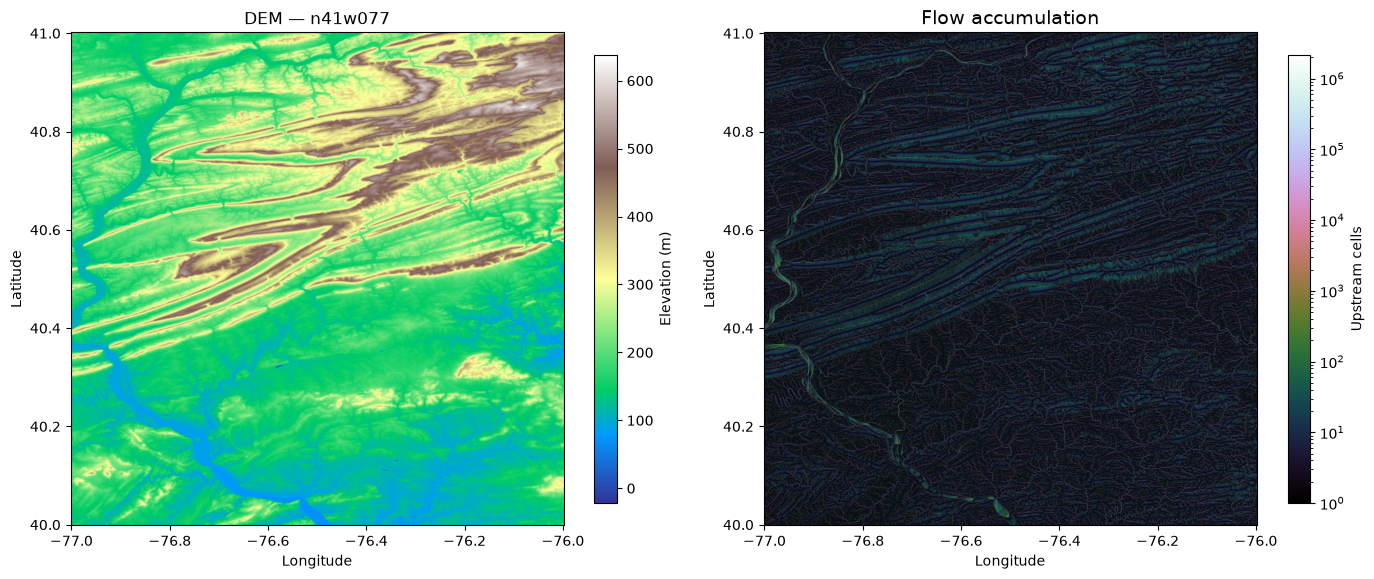

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(
    np.where(np.asarray(dem) == dem.nodata, np.nan, dem),
    extent=grid.extent, cmap="terrain",
)
plt.colorbar(im0, ax=axes[0], label="Elevation (m)", shrink=0.8)
axes[0].set_title("DEM — n41w077")

im1 = axes[1].imshow(
    acc, extent=grid.extent, cmap="cubehelix",
    norm=colors.LogNorm(1, acc.max()), interpolation="bilinear",
)
plt.colorbar(im1, ax=axes[1], label="Upstream cells", shrink=0.8)
axes[1].set_title("Flow accumulation", size=14)

for ax in axes:
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

#### Computing the height above nearest drainage


In [14]:
# Compute height above nearest drainage
hand = grid.compute_hand(fdir, dem, channels)
hand = np.asarray(hand, dtype="float32")

print(f"HAND range: {np.nanmin(hand):.1f} to {np.nanmax(hand):.1f} m")
print(f"undefined (no drainage path): {100 * np.isnan(hand).mean():.2f}%")
print(f"negative values:              {100 * (hand < 0).mean():.2f}%")

HAND range: -70.5 to 379.5 m
undefined (no drainage path): 0.70%
negative values:              0.41%


HAND range after cleaning: 0.0 to 379.5 m


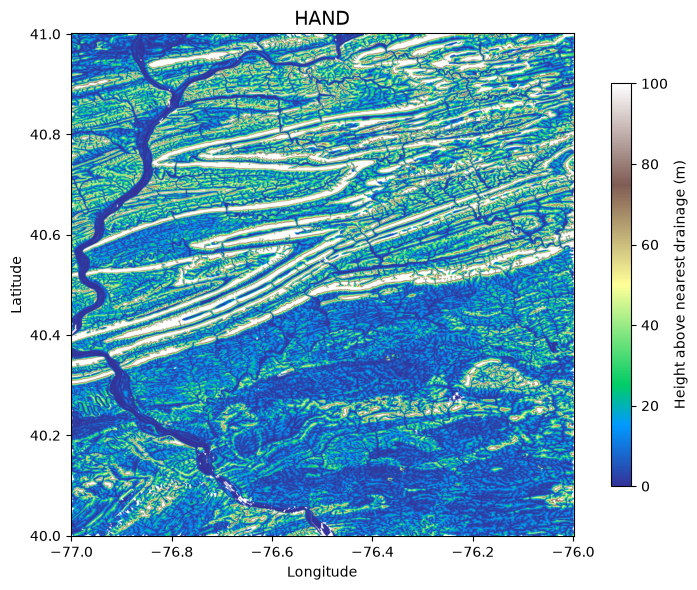

In [15]:
hand[np.asarray(dem) == dem.nodata] = np.nan   # mask the DEM's own nodata
hand[hand < 0] = 0                             # cells at or below their channel

print(f"HAND range after cleaning: {np.nanmin(hand):.1f} to {np.nanmax(hand):.1f} m")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(hand, extent=grid.extent, cmap="terrain", vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label="Height above nearest drainage (m)", shrink=0.8)
plt.title("HAND", size=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

#### Estimating inundation extent (constant channel depth)

inundated at a 5 m channel depth: 24.7% of the tile's valid cells


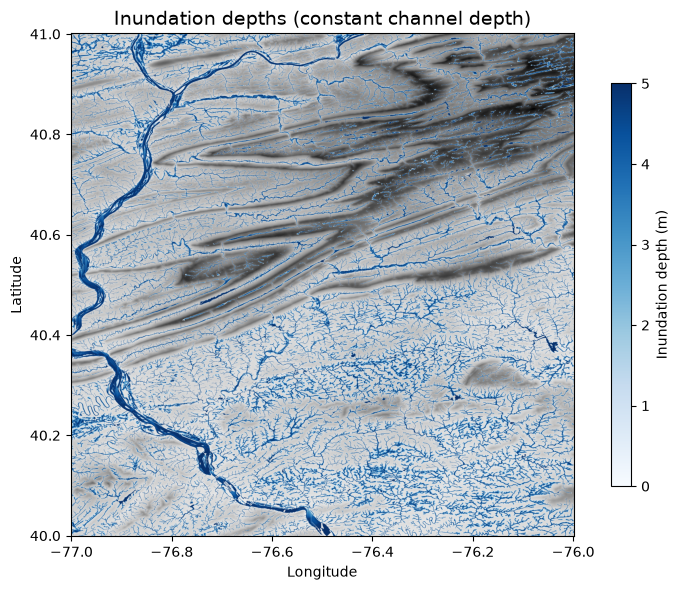

In [16]:
threshold = DEPTH_THRESHOLD
inundation_extent = np.where(hand < threshold, threshold - hand, np.nan).astype("float32")

flooded_pct = 100 * np.isfinite(inundation_extent).sum() / np.isfinite(hand).sum()
print(f"inundated at a {threshold} m channel depth: {flooded_pct:.1f}% of the tile's valid cells")

fig, ax = plt.subplots(figsize=(8, 6))
dem_view = np.where(np.asarray(dem) == dem.nodata, np.nan, dem)
plt.imshow(dem_view, extent=grid.extent, cmap="Greys", zorder=1)
plt.imshow(inundation_extent, extent=grid.extent, cmap="Blues",
           vmin=0, vmax=threshold, zorder=2)
plt.colorbar(label="Inundation depth (m)", shrink=0.8)
plt.title("Inundation depths (constant channel depth)", size=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

## 5. Run every tile and export per-tile GeoTIFFs

In [17]:
def write_like(array, like_path, out_path):
    """Write a float32 array as a GeoTIFF using another raster's georeferencing."""
    with rio.open(like_path) as src:
        profile = src.profile

    profile.update(
        driver="GTiff", dtype="float32", count=1, nodata=np.nan,
        compress="lzw", tiled=True, blockxsize=512, blockysize=512,
    )

    with rio.open(out_path, "w", **profile) as dst:
        dst.write(array.astype("float32"), 1)

    return out_path


def process_tile(name, dem_path, acc_threshold=ACC_THRESHOLD,
                 depth_threshold=DEPTH_THRESHOLD, overwrite=False):
    """Run the HAND model on one DEM tile and export HAND + inundation depth."""
    hand_path = os.path.join(HAND_DIR, f"hand_{name}.tif")
    depth_path = os.path.join(DEPTH_DIR, f"depth_{name}.tif")

    if not overwrite and os.path.exists(hand_path) and os.path.exists(depth_path):
        return hand_path, depth_path, "cached"

    grid = Grid.from_raster(dem_path)
    dem = grid.read_raster(dem_path)

    # condition the DEM: pits, depressions, flats
    pit_filled_dem = grid.fill_pits(dem)
    flooded_dem = grid.fill_depressions(pit_filled_dem)
    inflated_dem = grid.resolve_flats(flooded_dem)

    # flow direction and accumulation
    fdir = grid.flowdir(inflated_dem)
    acc = grid.accumulation(fdir)

    # HAND
    hand = np.asarray(grid.compute_hand(fdir, dem, acc > acc_threshold), dtype="float32")
    hand[np.asarray(dem) == dem.nodata] = np.nan
    hand[hand < 0] = 0

    # inundation depth
    depth = np.where(hand < depth_threshold, depth_threshold - hand, np.nan).astype("float32")

    write_like(hand, dem_path, hand_path)
    write_like(depth, dem_path, depth_path)

    return hand_path, depth_path, "computed"

In [18]:
import time

hand_paths, depth_paths = [], []
t_start = time.time()

for n, name in enumerate(tiles, start=1):
    t0 = time.time()
    hand_path, depth_path, status = process_tile(name, dem_files[name])
    hand_paths.append(hand_path)
    depth_paths.append(depth_path)
    print(f"[{n:2d}/{len(tiles)}] {name}  {status:>8}  {time.time() - t0:5.1f}s")

print(f"\n{len(hand_paths)} tiles processed in {(time.time() - t_start) / 60:.1f} min")

[ 1/25] n40w081    cached    0.0s
[ 2/25] n40w080    cached    0.0s
[ 3/25] n40w079    cached    0.0s
[ 4/25] n40w078    cached    0.0s
[ 5/25] n40w077    cached    0.0s
[ 6/25] n40w076    cached    0.0s
[ 7/25] n41w081    cached    0.0s
[ 8/25] n41w080    cached    0.0s
[ 9/25] n41w079    cached    0.0s
[10/25] n41w078    cached    0.0s
[11/25] n41w077    cached    0.0s
[12/25] n41w076    cached    0.0s
[13/25] n41w075    cached    0.0s
[14/25] n42w081    cached    0.0s
[15/25] n42w080    cached    0.0s
[16/25] n42w079    cached    0.0s
[17/25] n42w078    cached    0.0s
[18/25] n42w077    cached    0.0s
[19/25] n42w076    cached    0.0s
[20/25] n42w075    cached    0.0s
[21/25] n43w081    cached    0.0s
[22/25] n43w080    cached    0.0s
[23/25] n43w079    cached    0.0s
[24/25] n43w078    cached    0.0s
[25/25] n43w077    cached    0.0s

25 tiles processed in 0.0 min


## 6. Mosaic the tiles into statewide GeoTIFFs

In [19]:
from rasterio.merge import merge


def mosaic(paths, out_path, bounds):
    """Merge same-grid rasters into a single GeoTIFF cropped to `bounds`."""
    sources = [rio.open(p) for p in paths]
    data, transform = merge(sources, bounds=tuple(bounds))

    profile = sources[0].profile
    profile.update(height=data.shape[1], width=data.shape[2],
                   transform=transform, BIGTIFF="YES")

    with rio.open(out_path, "w", **profile) as dst:
        dst.write(data)

    for s in sources:
        s.close()

    return out_path


hand_mosaic = mosaic(hand_paths, os.path.join(MOSAIC_DIR, "pa_hand.tif"), pa.total_bounds)
depth_mosaic = mosaic(depth_paths,
                      os.path.join(MOSAIC_DIR, f"pa_depth_{DEPTH_THRESHOLD}m.tif"),
                      pa.total_bounds)

for path in (hand_mosaic, depth_mosaic):
    with rio.open(path) as src:
        print(f"{os.path.basename(path)}: {src.width} x {src.height} cells, "
              f"{src.crs}, {os.path.getsize(path) / 1024 ** 2:.0f} MB")

pa_hand.tif: 20989 x 10067 cells, EPSG:4269, 756 MB
pa_depth_5m.tif: 20989 x 10067 cells, EPSG:4269, 143 MB


## 7. Statewide maps

In [20]:
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds


def read_overview(path, max_dim=2000):
    """Read a raster downsampled so its longest side is at most `max_dim`."""
    with rio.open(path) as src:
        scale = max(src.width, src.height) / max_dim
        data = src.read(
            1,
            out_shape=(int(src.height / scale), int(src.width / scale)),
            resampling=Resampling.average,
        )
        bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    transform = from_bounds(*bounds, data.shape[1], data.shape[0])
    return data, extent, transform


hand_small, extent, transform = read_overview(hand_mosaic)

# the mosaic covers PA's bounding box, so blank out everything outside the state
outside = geometry_mask([pa_geom], out_shape=hand_small.shape,
                        transform=transform, invert=False)
hand_small[outside] = np.nan

depth_small = np.where(hand_small < DEPTH_THRESHOLD, DEPTH_THRESHOLD - hand_small, np.nan)

print("overview size:", hand_small.shape)
print(f"below the {DEPTH_THRESHOLD} m flood level: "
      f"{100 * np.isfinite(depth_small).sum() / np.isfinite(hand_small).sum():.1f}% of the state")

overview size: (959, 2000)
below the 5 m flood level: 12.8% of the state


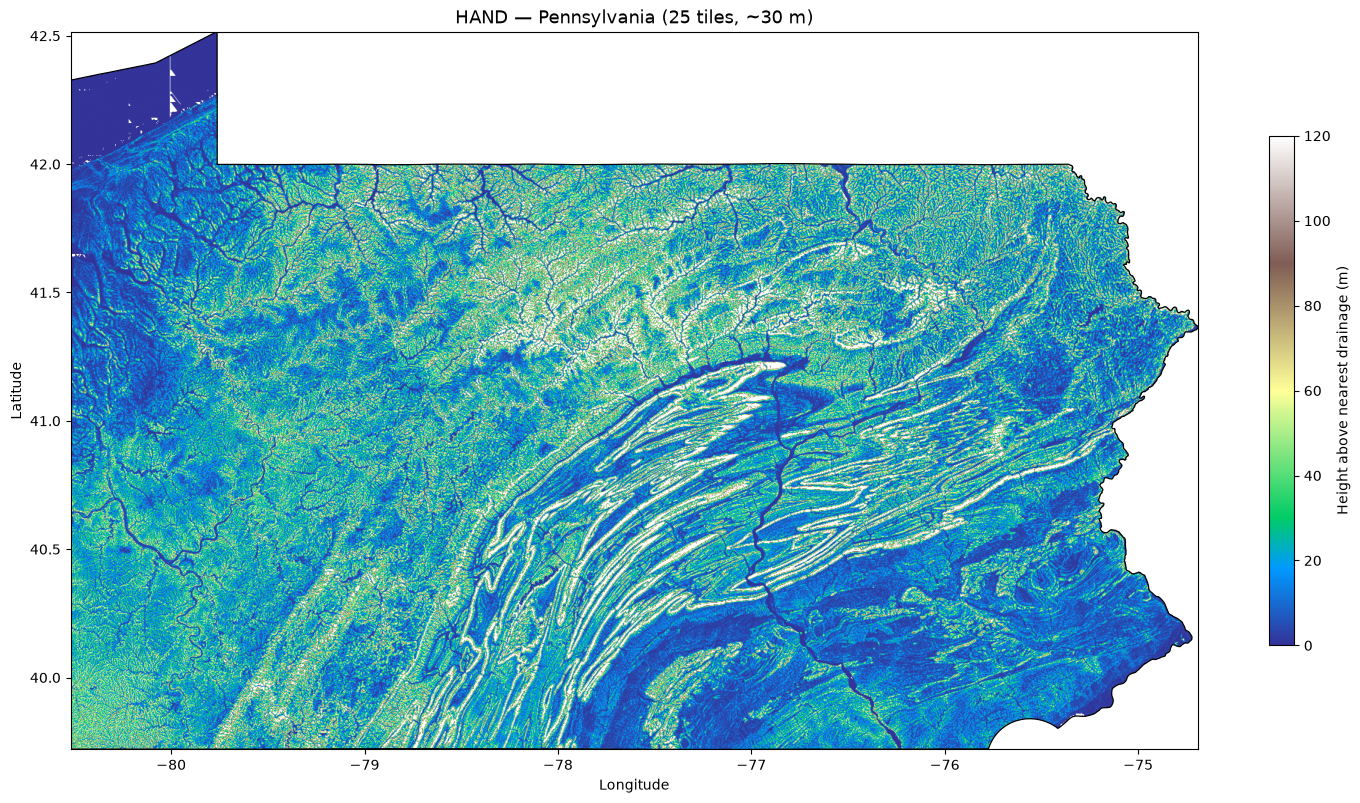

In [21]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(hand_small, extent=extent, cmap="terrain", vmin=0, vmax=120)
pa.boundary.plot(ax=ax, color="black", linewidth=0.9)

plt.colorbar(im, ax=ax, label="Height above nearest drainage (m)", shrink=0.7)
ax.set_title(f"HAND — Pennsylvania ({len(tiles)} tiles, ~30 m)", size=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(os.path.join(MOSAIC_DIR, "pa_hand_map.png"), dpi=200, bbox_inches="tight")
plt.show()

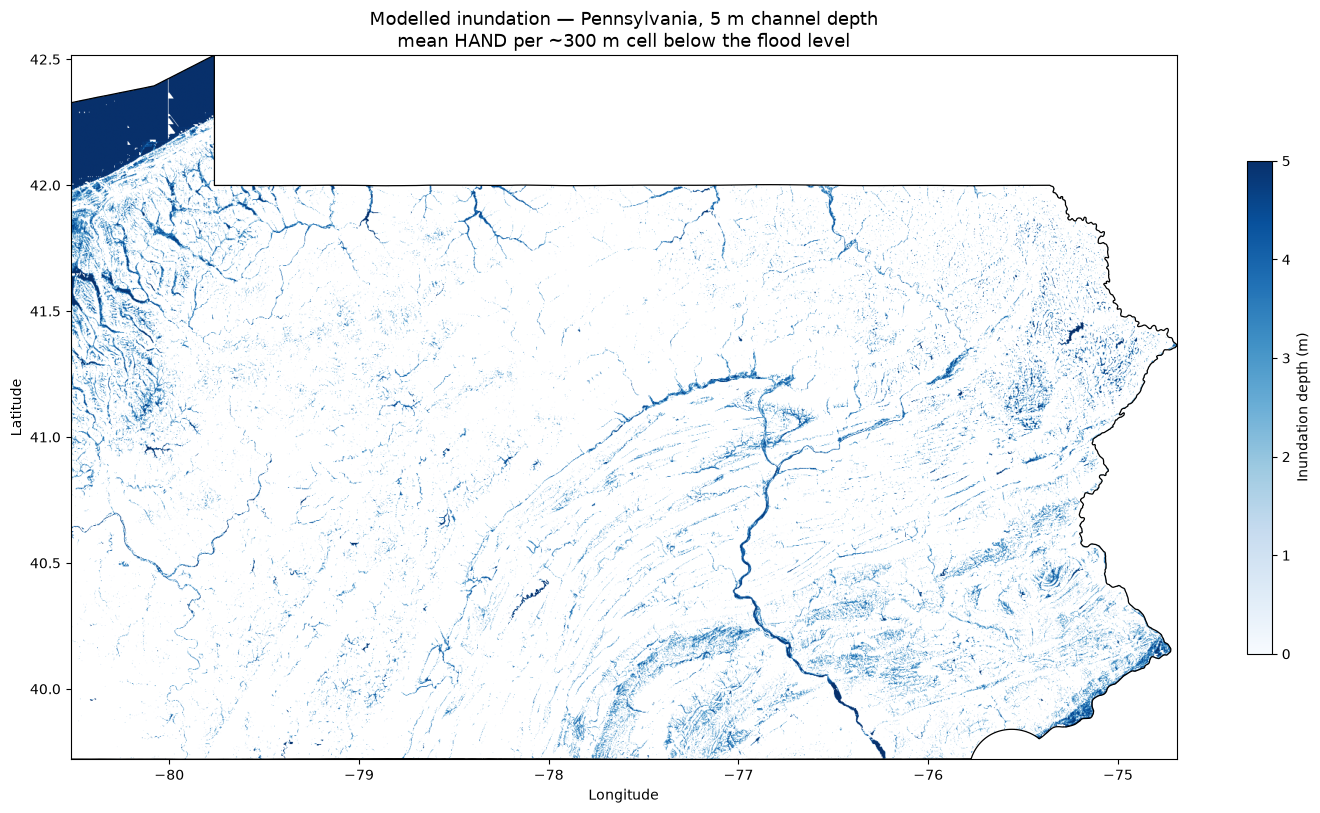

In [22]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(depth_small, extent=extent, cmap="Blues", vmin=0, vmax=DEPTH_THRESHOLD)
pa.boundary.plot(ax=ax, color="black", linewidth=0.9)

plt.colorbar(im, ax=ax, label="Inundation depth (m)", shrink=0.7)
ax.set_title(f"Modelled inundation — Pennsylvania, {DEPTH_THRESHOLD} m channel depth\n"
             "mean HAND per ~300 m cell below the flood level", size=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig(os.path.join(MOSAIC_DIR, f"pa_inundation_{DEPTH_THRESHOLD}m_map.png"),
            dpi=200, bbox_inches="tight")
plt.show()